# ***Project Title: End-to-End Sales Forecasting & Demand Intelligence System***

## ***Task 1 — Data Loading, Merging & Deep Exploration***

In [223]:
# Importing basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Importing the time series decompositon library
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller # ADF test
# sarimax model
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima # model used to get parameters of sarima

#importing the prophet model
from prophet import Prophet

# XGBoost
from xgboost import XGBRegressor

# Importing Isolation Forest
from sklearn.ensemble import IsolationForest

# Importing for Scaling data and K-Means CLustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Importing PCA
from sklearn.decomposition import PCA
# Importing metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Warnings
import os
os.environ['OMP_NUM_THREADS'] = '1'

In [128]:
df_store= pd.read_csv('train.csv')
df_store

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [129]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [130]:
# Parsing the "Order Date" and "Ship Date" columns as Datetime objects
df_store[['Order Date',	'Ship Date']]= df_store[['Order Date', 'Ship Date']].apply(pd.to_datetime,dayfirst=True, errors='coerce')
df_store

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [131]:
df_store.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [132]:
# Sorting the columns of Order and ship Date
df_store.sort_values(['Order Date','Ship Date'], ascending=False, inplace=True)
df_store

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
645,646,CA-2018-126221,2018-12-30,2019-01-05,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,Indiana,47201.0,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300
906,907,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009.0,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",323.136
907,908,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009.0,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930
908,909,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009.0,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776
1296,1297,CA-2018-115427,2018-12-30,2019-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,94533.0,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1759,1760,CA-2015-141817,2015-01-05,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536
739,740,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784
740,741,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736
741,742,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540


In [133]:
# Changing the index 
df_store=df_store.reset_index(drop=True)
df_store

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,646,CA-2018-126221,2018-12-30,2019-01-05,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,Indiana,47201.0,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300
1,907,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009.0,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",323.136
2,908,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009.0,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930
3,909,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009.0,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776
4,1297,CA-2018-115427,2018-12-30,2019-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,94533.0,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,1760,CA-2015-141817,2015-01-05,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536
9796,740,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784
9797,741,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736
9798,742,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540


### *Extracting Time features*

In [134]:
# Extracting the year and adding to dataset
df_store['Year']= df_store['Order Date'].dt.year 
df_store['Year']

0       2018
1       2018
2       2018
3       2018
4       2018
        ... 
9795    2015
9796    2015
9797    2015
9798    2015
9799    2015
Name: Year, Length: 9800, dtype: int32

In [135]:
# Extracting the month and adding to dataset
df_store['Month']= df_store['Order Date'].dt.month
df_store['Month']

0       12
1       12
2       12
3       12
4       12
        ..
9795     1
9796     1
9797     1
9798     1
9799     1
Name: Month, Length: 9800, dtype: int32

In [136]:
# Extracting the Day of week and adding to dataset
df_store['Day']=df_store['Order Date'].dt.day_name()
df_store['Day']

0         Sunday
1         Sunday
2         Sunday
3         Sunday
4         Sunday
          ...   
9795      Monday
9796      Sunday
9797      Sunday
9798      Sunday
9799    Saturday
Name: Day, Length: 9800, dtype: object

In [137]:
# Extracting the week number and adding to dataset
df_store['Week_nos']=df_store['Order Date'].dt.isocalendar().week
df_store['Week_nos']

0       52
1       52
2       52
3       52
4       52
        ..
9795     2
9796     1
9797     1
9798     1
9799     1
Name: Week_nos, Length: 9800, dtype: UInt32

In [138]:
# Extracting the quarter and adding to dataset
df_store['Quarter']=df_store['Order Date'].dt.quarter
df_store['Quarter']

0       4
1       4
2       4
3       4
4       4
       ..
9795    1
9796    1
9797    1
9798    1
9799    1
Name: Quarter, Length: 9800, dtype: int32

In [139]:
# Extracting the Seasons and adding to dataset
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"
        
df_store['Season']=df_store['Month'].apply(get_season)
df_store['Season']

0       Winter
1       Winter
2       Winter
3       Winter
4       Winter
         ...  
9795    Winter
9796    Winter
9797    Winter
9798    Winter
9799    Winter
Name: Season, Length: 9800, dtype: object

In [140]:
# Checking the whole dataset with new added columns
df_store

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Day,Week_nos,Quarter,Season
0,646,CA-2018-126221,2018-12-30,2019-01-05,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,...,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300,2018,12,Sunday,52,4,Winter
1,907,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",323.136,2018,12,Sunday,52,4,Winter
2,908,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,Technology,Phones,Gear Head AU3700S Headset,90.930,2018,12,Sunday,52,4,Winter
3,909,CA-2018-143259,2018-12-30,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,2018,12,Sunday,52,4,Winter
4,1297,CA-2018-115427,2018-12-30,2019-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2018,12,Sunday,52,4,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,1760,CA-2015-141817,2015-01-05,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,2015,1,Monday,2,1,Winter
9796,740,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Labels,Avery 508,11.784,2015,1,Sunday,1,1,Winter
9797,741,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,2015,1,Sunday,1,1,Winter
9798,742,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2015,1,Sunday,1,1,Winter


In [141]:
# Checking null values
df_store.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Day               0
Week_nos          0
Quarter           0
Season            0
dtype: int64

#### In the above code, we get to know there are 11 null values in Postal Code column which is < 0.1% of the total dataset. But since this is a real dataset we cannot remove them, so we leave them as it is, as the Postal Column won't be used much.

In [142]:
# Checking Duplicates
df_store.duplicated().sum()

0

In [143]:
# Checking the datatype
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

### *Note: The dataype for Order Date and Ship Date columns were handled before*
###  *In the Postal column, I noticed the datatype as float64 but it should be an object datatype since we do not perfom any operations on that column. But we cannot convert it into object as it contains some null values*

In [144]:
# Aggregating data into Monthly and Weekly Totals
# Monthly data
df_month= df_store.groupby(pd.Grouper(key='Order Date',freq='ME'))['Sales'].sum().reset_index()
df_month= df_month.set_index('Order Date')
df_month

,Sales
Order Date,
2015-01-31,14205.7070
2015-02-28,4519.8920
2015-03-31,55205.7970
2015-04-30,27906.8550
2015-05-31,23644.3030
2015-06-30,34322.9356
2015-07-31,33781.5430
2015-08-31,27117.5365
2015-09-30,81623.5268


In [145]:
# Weekly data
df_weekly= df_store.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
df_weekly= df_weekly.set_index('Order Date')
df_weekly

,Sales
Order Date,
2015-01-04,304.5080
2015-01-11,4619.1080
2015-01-18,4130.5330
2015-01-25,3092.5440
2015-02-01,2527.9140
...,...
2018-12-02,35998.9000
2018-12-09,21537.2410
2018-12-16,11542.8340


In [146]:
# Original dataset columns for answering the questions
df_store.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Day', 'Week_nos', 'Quarter',
       'Season'],
      dtype='object')

In [147]:
# Highest total revenue of a product category
df_store.groupby("Category")['Sales'].sum().sort_values(ascending=False).head(1)

Category
Technology    827455.873
Name: Sales, dtype: float64

### The category with the highest total revenue is *Technology*

In [148]:
# Consistent Sales growth of the region
res= df_store.pivot_table(index='Region', columns='Year',values='Sales', aggfunc='sum')
res #getting the year and region in one dataframe

Year,2015,2016,2017,2018
Region,,,,
Central,102920.5206,102425.1724,145673.8800,141627.3402
East,127652.8190,153225.1830,178511.5380,210129.1860
South,103374.9055,70076.0825,93535.9035,122164.5675
West,145907.9630,133709.5675,182471.2285,248130.9255


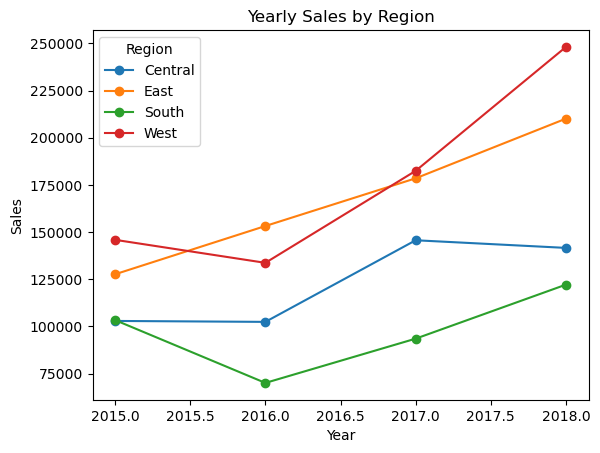

In [241]:
res.T.plot(marker='o')
plt.title('Yearly Sales by Region')
plt.ylabel('Sales')
plt.savefig('yearly sales.png', dpi=300, bbox_inches='tight')
plt.show()

### From the above graph, we can see that Region ***East*** is consistent in the sales growth over the 4 years

In [150]:
# Average Difference between Order Date and Ship Date
diff= df_store['Ship Date'] - df_store['Order Date']
diff.mean()

Timedelta('3 days 23:04:00.979591836')

### The average time between Order Date and Ship Date is **3 Days**

In [151]:
# Variance with region check
df_store.groupby("Region").apply(lambda x: (x['Ship Date'] - x['Order Date']).mean())

C:\Users\singh\AppData\Local\Temp\ipykernel_2640\2189895282.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_store.groupby("Region").apply(lambda x: (x['Ship Date'] - x['Order Date']).mean())


Region
Central   4 days 01:34:51.699604743
East      3 days 21:50:44.165170556
South     3 days 23:04:07.809762202
West      3 days 22:19:34.012738853
dtype: timedelta64[ns]

### From the above we get to know that the average time between the Order Date and Ship Date vary only in the **Central region(4 days)**, other all regions have the same average

In [152]:
# seasonality check
ssn= df_store.pivot_table(index='Month', columns='Year', values='Sales', aggfunc='sum')
ssn

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


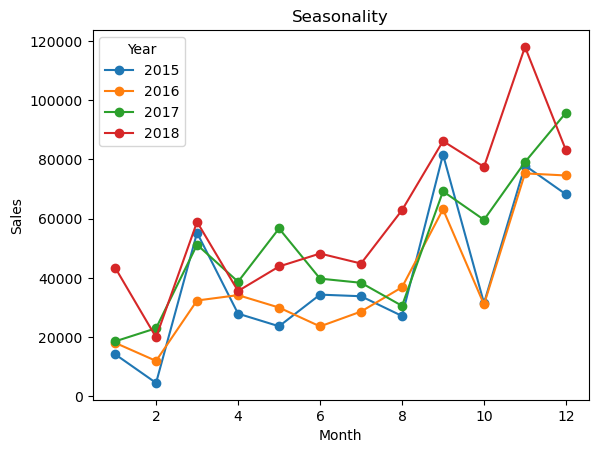

In [240]:
# plotting the seasonality
ssn.plot(marker='o')
plt.title('Seasonality')
plt.ylabel('Sales')
plt.savefig('seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

### From the above graph, we can observe that Months; **March(3), September(9) and November(11)** are the ones that consistently spike in throughout al the years.

## ***Task 2 — Time Series Analysis & Decomposition***

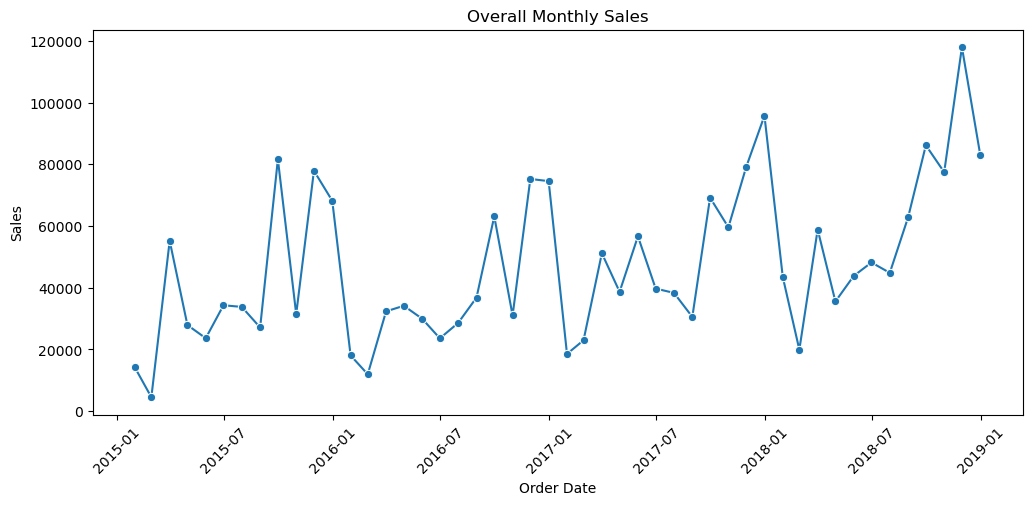

In [239]:
# Monthly Sales Trend across 4 Years
plt.figure(figsize=(12,5))
sns.lineplot(df_month, x='Order Date', y='Sales', marker='o' )
plt.xticks(rotation=45)
plt.title('Overall Monthly Sales')
plt.savefig('Monthly Sales .png', dpi=300, bbox_inches='tight')

plt.show()

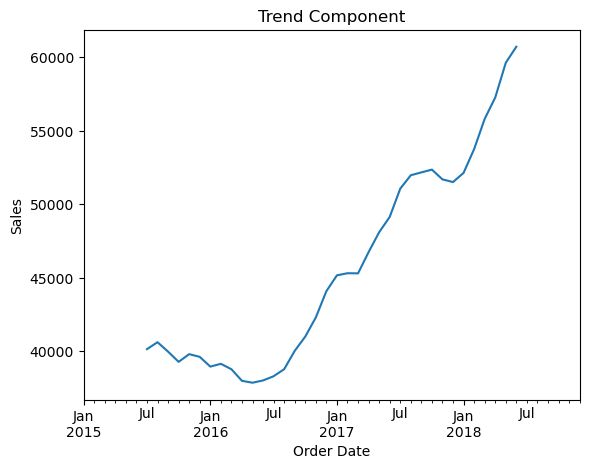

In [238]:
# Time Series Decomposition
decomp_res= seasonal_decompose(df_month['Sales'], model='multiplicative', period=12)

#Trend component
decomp_res.trend.plot(title='Trend Component')
plt.ylabel('Sales')
plt.savefig('Trend component.png', dpi=300, bbox_inches='tight')

plt.show()

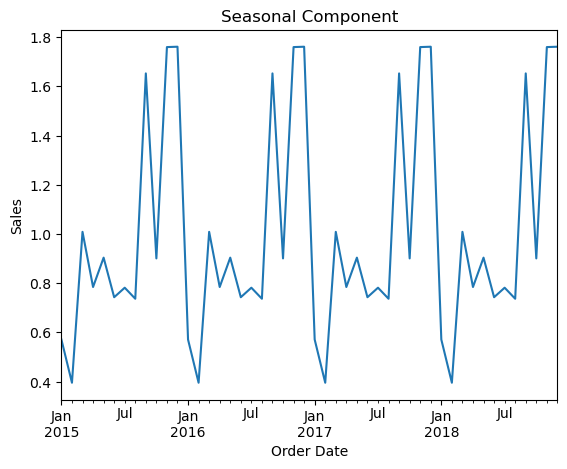

In [237]:
# Seasonal Component
decomp_res.seasonal.plot(title='Seasonal Component')
plt.ylabel('Sales')
plt.savefig('Seasonal Component.png', dpi=300, bbox_inches='tight')

plt.show()

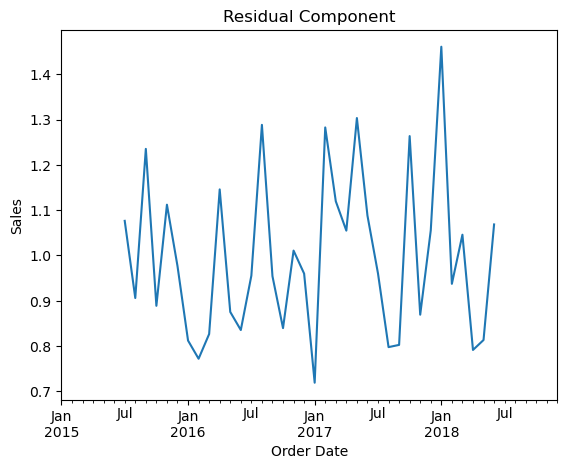

In [242]:
decomp_res.resid.plot(title='Residual Component')
plt.ylabel('Sales')
plt.savefig('Residual.png', dpi=300, bbox_inches='tight')

plt.show()

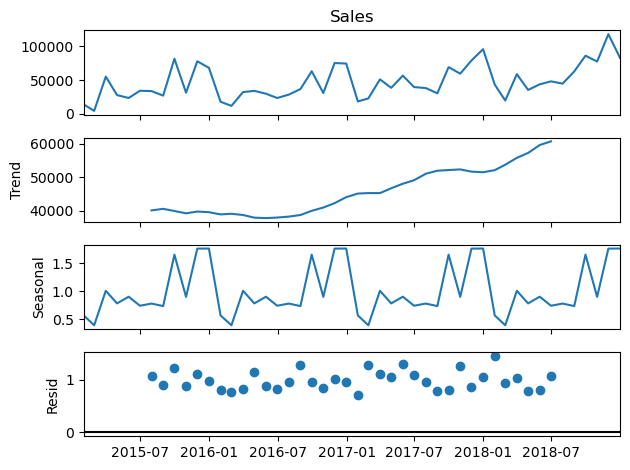

In [243]:
# ALl In One Plot
decomp_res.plot()
plt.savefig('ALLINONE.png', dpi=300, bbox_inches='tight')
plt.show()

### From the above plot of the components, we can observe the following:
#### 1) The Original Sales data is mapped and can see all the sales in the 4 years.
#### 2) There is an upward(increasing) trend in the sales for the 4 years.
#### 3) The Seasonality is very strong is tells us that there is a pattern in rise and dip of the sales. The sales increase in the month of October and then dips in November. It increases again in the month of December and then dips again in the month of January. This pattern repeats in the 4 years
#### 4) Residual Noise stay close to 1.0 most of the time, meaning trend and seasonality explain sales well, except for a clear spike in early 2018 that looks like an anomaly.


In [159]:
# Stationarity Check
stat=adfuller(df_month['Sales'])
print(f"p-value is: {stat[1]}")


p-value is: 0.00027791039276670623


### Since p-value is much less than 0.05, the data is stationary. Hence there is **no need to use Differencing** as it is used only for non stationary data

#### Stationarity: The property which tells us whether the data's statistical properties such as mean, variance and pattern are constant or not. If a Time Series data is stationary it means that the mean, variance are constant over time.
#### The Augmented Dickey-Fuller (ADF) Test tells us this by calculating the p-value. If p-value<0.05, data is stationary or otherwise.

## ***Task 3 — Sales Forecasting using 3 Different Models***

### *Note: The statmodels module is already installed, so I have not installed it again*

### ***Model 1: SARIMA***

In [160]:
# Finding the best parameters for SARIMA
model_arima= auto_arima(df_month['Sales'], seasonal=True, m=12, trace=True)
print(model_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1079.923, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1096.560, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1076.500, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1077.487, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1094.708, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1089.579, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1078.250, Time=0.37 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1078.452, Time=0.19 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1080.901, Time=0.13 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1079.864, Time=0.65 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1084.035, Time=0.09 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1073.635, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1087.151, Time=0.07 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1075.267, Time=0.44 sec
 ARIMA(2,1,0)(1,0,1

### The optimized parameters found by the auto arima model are; *p=2, d=1, q=0* : **P=1, D=0, Q=0, m=12**
#### Note: The auto arima selected d=1 according to its own method known as KPSS(Differencing used on its own according to KPSS), whereas according to ADF Test, d=0(no differencing is used).

In [161]:
# Fitting Sarima model on monthly sales
final_model = SARIMAX(df_month['Sales'], order=(2,1,0), seasonal_order=(1,0,0,12)).fit()
#3 month future forecast with confidence interval
future_forecast = final_model.get_forecast(steps=3)
future_pred = future_forecast.predicted_mean
conf_int = future_forecast.conf_int(alpha=0.05) 

print(future_pred)
print(conf_int)

2019-01-31    71457.294735
2019-02-28    55170.675662
2019-03-31    75354.273326
Freq: ME, Name: predicted_mean, dtype: float64
             lower Sales    upper Sales
2019-01-31  26519.448450  116395.141020
2019-02-28   6856.399003  103484.952320
2019-03-31  21594.176460  129114.370193


C:\Users\singh\NewAnaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\singh\NewAnaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


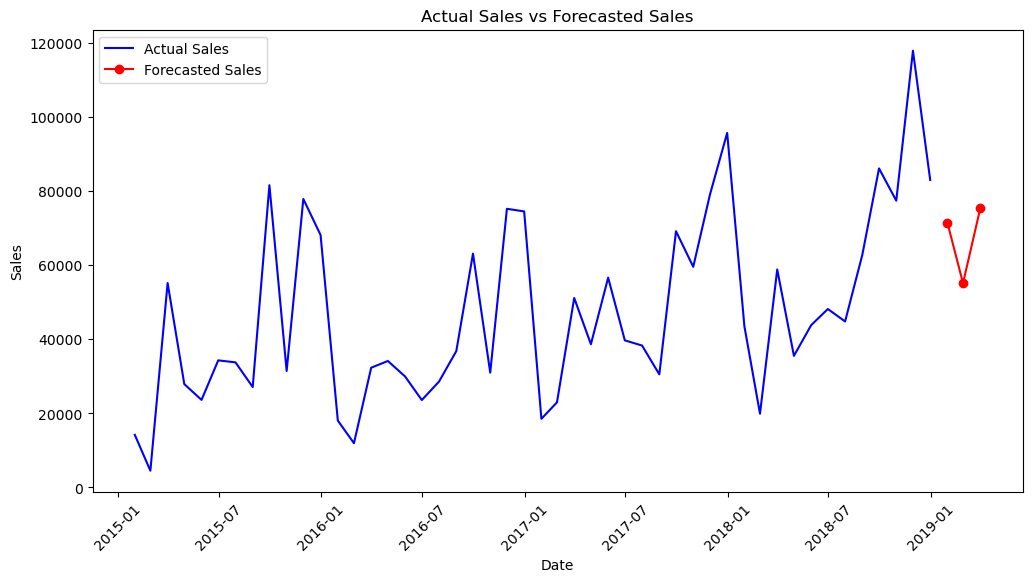

In [245]:
#Plotting the actual vs forecasted sales
plt.figure(figsize=(12,6))

# Actual historical sales
plt.plot(df_month.index, df_month['Sales'], label='Actual Sales', color='blue')

# Forecasted sales
plt.plot(future_pred.index, future_pred, label='Forecasted Sales', color='red', marker='o')


plt.title('Actual Sales vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.savefig('SARIMAForecasted.png', dpi=300, bbox_inches='tight')
plt.show()

### ***Model 2: Facebook Prophet Model***

In [163]:
# Initializing Prophet Model
model_pht= Prophet()
# Preparing the data in the Prophet format
df_prophet= df_month.reset_index().rename(columns= {'Order Date': 'ds', 'Sales': 'y'})
df_prophet

,ds,y
0,2015-01-31,14205.7070
1,2015-02-28,4519.8920
2,2015-03-31,55205.7970
3,2015-04-30,27906.8550
4,2015-05-31,23644.3030
5,2015-06-30,34322.9356
6,2015-07-31,33781.5430
7,2015-08-31,27117.5365
8,2015-09-30,81623.5268
9,2015-10-31,31453.3930


In [164]:
# Training the model
model_pht.fit(df_prophet)

18:48:34 - cmdstanpy - INFO - Chain [1] start processing
18:48:34 - cmdstanpy - INFO - Chain [1] done processing


In [165]:
# Forecasting
future_pred_pht= model_pht.make_future_dataframe(periods=3, freq='ME')
forecast= model_pht.predict(future_pred_pht)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33505.686141,5163.111758,23620.062598,33505.686141,33505.686141,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,14300.788630
1,2015-02-28,33906.289832,-7118.990128,11350.124185,33906.289832,33906.289832,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,2292.490775
2,2015-03-31,34349.815347,43109.829556,61760.763982,34349.815347,34349.815347,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,52016.921025
3,2015-04-30,34779.033587,12151.655903,29898.261808,34779.033587,34779.033587,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,0.0,0.0,0.0,21123.413134
4,2015-05-31,35222.559103,13493.874095,32092.553670,35222.559103,35222.559103,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,0.0,0.0,0.0,22726.497781
5,2015-06-30,35651.777346,20590.304066,39288.824860,35651.777346,35651.777346,-5734.101810,-5734.101810,-5734.101810,-5734.101810,-5734.101810,-5734.101810,0.0,0.0,0.0,29917.675536
6,2015-07-31,36095.302862,16751.032760,35245.767377,36095.302862,36095.302862,-10254.212008,-10254.212008,-10254.212008,-10254.212008,-10254.212008,-10254.212008,0.0,0.0,0.0,25841.090855
7,2015-08-31,36538.828378,15171.992338,33704.754754,36538.828378,36538.828378,-11634.519898,-11634.519898,-11634.519898,-11634.519898,-11634.519898,-11634.519898,0.0,0.0,0.0,24904.308481
8,2015-09-30,36968.046618,61291.386058,79440.121020,36968.046618,36968.046618,33781.506294,33781.506294,33781.506294,33781.506294,33781.506294,33781.506294,0.0,0.0,0.0,70749.552912
9,2015-10-31,37411.572133,28197.653019,47207.965451,37411.572133,37411.572133,658.119434,658.119434,658.119434,658.119434,658.119434,658.119434,0.0,0.0,0.0,38069.691567


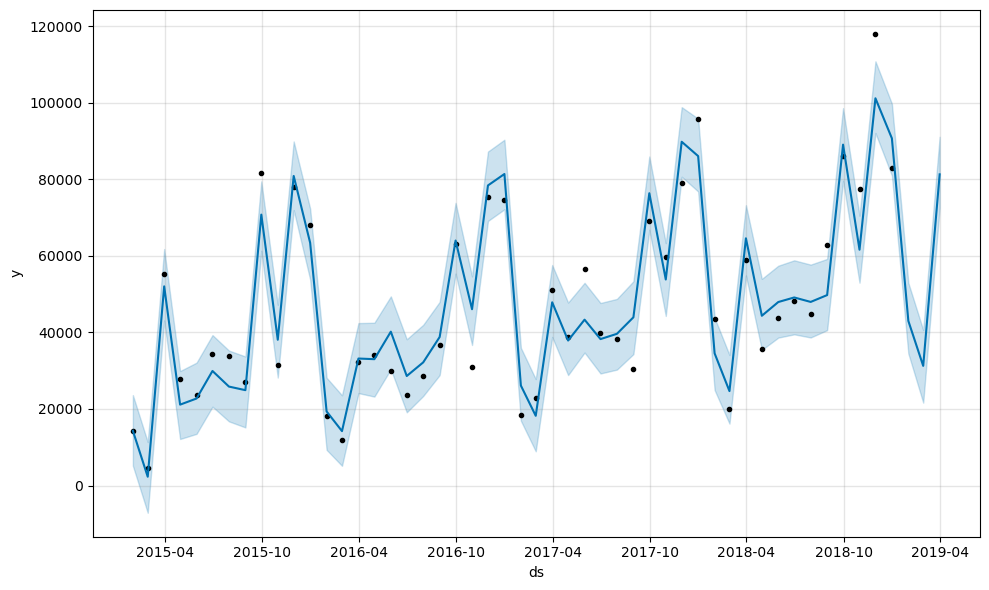

In [246]:
# Prophet Model Forecast
model_pht.plot(forecast)
plt.savefig('PROPHETFORECAST.png', dpi=300, bbox_inches='tight')
plt.show()

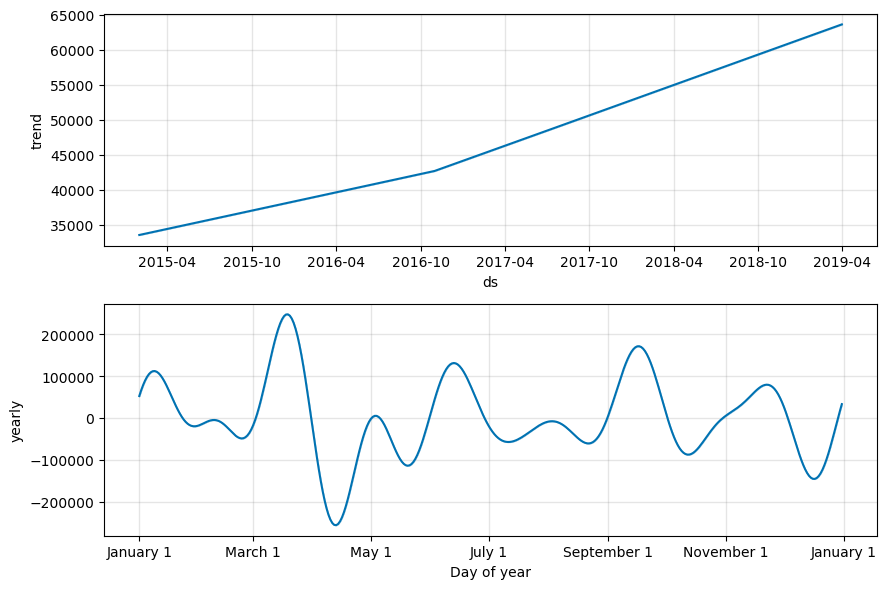

In [247]:
# Trend and Seasonality Component Breakdown
model_pht.plot_components(forecast)
plt.savefig('TrendseasonalityPROPHET.png', dpi=300, bbox_inches='tight')

plt.show()

22:10:28 - cmdstanpy - INFO - Chain [1] start processing
22:10:29 - cmdstanpy - INFO - Chain [1] done processing


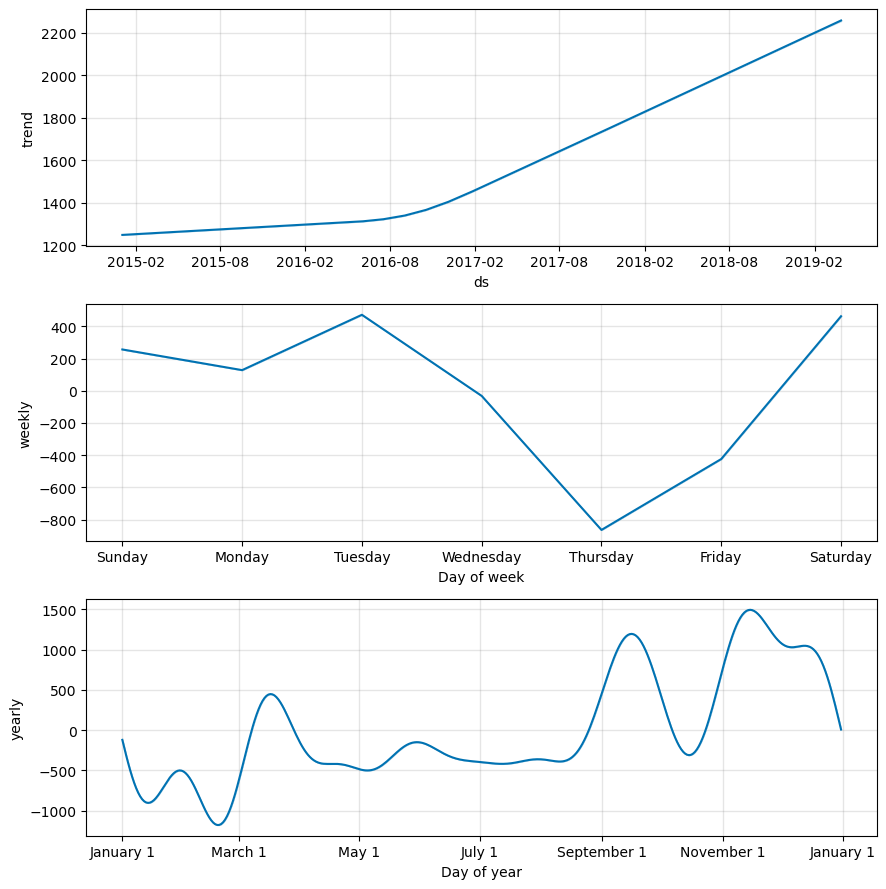

In [248]:
# weekly prophet model forecast
df_daily = df_store.groupby(pd.Grouper(key='Order Date', freq='D'))['Sales'].sum().reset_index()
df_daily = df_daily.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

model_daily = Prophet()
model_daily.fit(df_daily)

future_daily = model_daily.make_future_dataframe(periods=90)  
forecast_daily = model_daily.predict(future_daily)

model_daily.plot_components(forecast_daily)
plt.savefig('weekly prophet.png', dpi=300, bbox_inches='tight')

plt.show()

### ***Model 3: XGBoost Regressor***

In [169]:
# Conversion of Time Series into lag features
df_xgb = df_month.copy()
df_xgb['lag1'] = df_xgb['Sales'].shift(1)
df_xgb['lag2'] = df_xgb['Sales'].shift(2)
df_xgb['lag3'] = df_xgb['Sales'].shift(3)
df_xgb['rolling_mean3'] = df_xgb['Sales'].shift(1).rolling(3).mean()

df_xgb['Month'] = df_xgb.index.month
df_xgb['Quarter'] = df_xgb.index.quarter
df_xgb['Season'] = df_xgb['Month'] % 12 // 3 + 1  

df_xgb = df_xgb.dropna()  
print(df_xgb)


                  Sales         lag1        lag2        lag3  rolling_mean3  \
Order Date                                                                    
2015-04-30   27906.8550   55205.7970   4519.8920  14205.7070   24643.798667   
2015-05-31   23644.3030   27906.8550  55205.7970   4519.8920   29210.848000   
2015-06-30   34322.9356   23644.3030  27906.8550  55205.7970   35585.651667   
2015-07-31   33781.5430   34322.9356  23644.3030  27906.8550   28624.697867   
2015-08-31   27117.5365   33781.5430  34322.9356  23644.3030   30582.927200   
2015-09-30   81623.5268   27117.5365  33781.5430  34322.9356   31740.671700   
2015-10-31   31453.3930   81623.5268  27117.5365  33781.5430   47507.535433   
2015-11-30   77907.6607   31453.3930  81623.5268  27117.5365   46731.485433   
2015-12-31   68167.0585   77907.6607  31453.3930  81623.5268   63661.526833   
2016-01-31   18066.9576   68167.0585  77907.6607  31453.3930   59176.037400   
2016-02-29   11951.4110   18066.9576  68167.0585  77

In [170]:
# Extracting the features
features = ['lag1', 'lag2', 'lag3', 'rolling_mean3', 'Month', 'Quarter', 'Season']
X = df_xgb[features]
y = df_xgb['Sales']

X_train, X_test = X[:-3], X[-3:]
y_train, y_test = y[:-3], y[-3:]

In [171]:
# Training the model and prediction
model_xgb = XGBRegressor(n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

In [172]:
# Prediction and Forecasting
history = list(df_xgb['Sales'].values)
future_dates = []
future_preds = []

last_date = df_xgb.index[-1]

for i in range(3):
    lag1, lag2, lag3 = history[-1], history[-2], history[-3]
    roll3 = np.mean(history[-3:])
    next_date = last_date + pd.DateOffset(months=i+1)
    
    row = pd.DataFrame([[lag1, lag2, lag3, roll3, next_date.month, next_date.quarter, (next_date.month%12//3+1)]], 
                        columns=features)
    
    next_pred = model_xgb.predict(row)[0]
    future_preds.append(next_pred)
    future_dates.append(next_date)
    history.append(next_pred)
# Predicted 3 months
future_series = pd.Series(future_preds, index=future_dates)
future_series

2019-01-31    43478.933594
2019-02-28    19920.998047
2019-03-31    58863.300781
dtype: float32

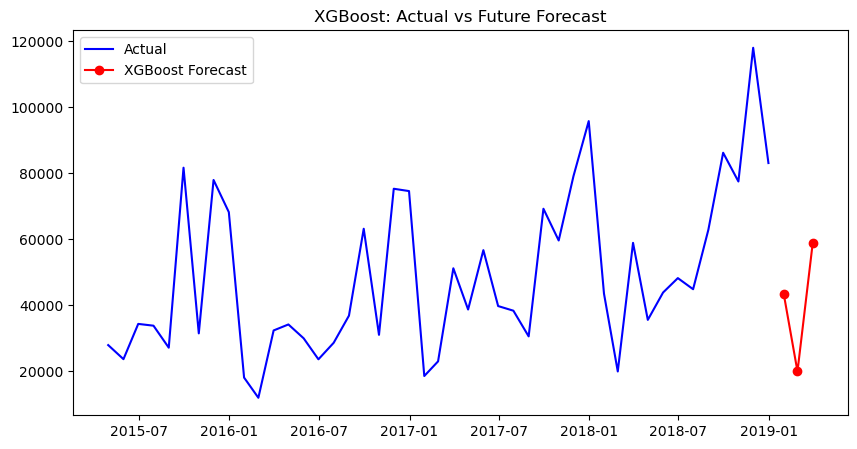

In [249]:
# Plotting Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(df_xgb.index, df_xgb['Sales'], label='Actual', color='blue')
plt.plot(future_series.index, future_series, label='XGBoost Forecast', color='red', marker='o')
plt.legend()
plt.title('XGBoost: Actual vs Future Forecast')
plt.savefig('XGBOOST.png', dpi=300, bbox_inches='tight')

plt.show()

In [174]:
# Metrics for SARIMA Model
train_monthly = df_month['Sales'][:-3]
test_monthly = df_month['Sales'][-3:]

model_sarima_test = SARIMAX(train_monthly, order=(2,1,0), seasonal_order=(1,0,0,12)).fit()
pred_sarima_test = model_sarima_test.get_forecast(steps=3).predicted_mean
pred_sarima_test.index = test_monthly.index

mae = mean_absolute_error(test_monthly, pred_sarima_test)
rmse = mean_squared_error(test_monthly, pred_sarima_test) ** 0.5
mape = (abs((test_monthly - pred_sarima_test) / test_monthly)).mean() * 100

C:\Users\singh\NewAnaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\singh\NewAnaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [175]:
# Metrics for Prophet Model
train_prophet = df_prophet[:-3]
test_prophet = df_prophet[-3:]

model_pht_test = Prophet()
model_pht_test.fit(train_prophet)
future_test_p = model_pht_test.make_future_dataframe(periods=3, freq='ME')
forecast_test_p = model_pht_test.predict(future_test_p)
pred_prophet_test = forecast_test_p[['ds','yhat']].tail(3)

mae_p = mean_absolute_error(test_prophet['y'], pred_prophet_test['yhat'])
rmse_p = mean_squared_error(test_prophet['y'], pred_prophet_test['yhat']) ** 0.5
mape_p = (abs((test_prophet['y'].values - pred_prophet_test['yhat'].values) / test_prophet['y'].values)).mean() * 100

18:48:41 - cmdstanpy - INFO - Chain [1] start processing
18:48:42 - cmdstanpy - INFO - Chain [1] done processing


In [176]:
# Metrics for XGBoost
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = mean_squared_error(y_test, pred_xgb) ** 0.5
mape_x = (abs((y_test.values - pred_xgb) / y_test.values)).mean() * 100

In [178]:
# Comparison Table
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mae, mae_p, mae_x],
    'RMSE': [rmse, rmse_p, rmse_x],
    'MAPE': [mape, mape_p, mape_x],
    'Forecast Month 1': [future_pred.iloc[0], forecast['yhat'].tail(3).iloc[0], future_preds[0]],
    'Forecast Month 2': [future_pred.iloc[1], forecast['yhat'].tail(3).iloc[1], future_preds[1]],
    'Forecast Month 3': [future_pred.iloc[2], forecast['yhat'].tail(3).iloc[2], future_preds[2]],
})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,15541.419286,18816.268096,15.490467,71457.294735,55170.675662,75354.273326
1,Prophet,20250.794435,22318.411382,21.864628,42990.532194,31248.159914,81267.007764
2,XGBoost,28900.234115,28940.505328,32.243174,43478.933594,19920.998047,58863.300781


In [179]:
# Best Model
best_model = comparison.loc[comparison['MAPE'].idxmin(), 'Model']
print(f"Recommended model: {best_model} (lowest MAPE at {comparison['MAPE'].min():.2f}%)")

Recommended model: SARIMA (lowest MAPE at 15.49%)


### I would recommend SARIMA for production since it has the lowest MAE, RMSE, and MAPE (15.5%) of the three models, meaning its forecasts stayed closest to actual sales. Prophet came second (21.9% MAPE), while XGBoost performed worst (32.2%) since it struggled to predict the sharp sales spike, a known weakness of tree-based models.

## ***Task 4 — Product Category & Region Level Forecasting***

In [182]:
# Extracting the required data for each segment
def get_monthly_series(df, column, value):
    filtered = df[df[column] == value]
    monthly = filtered.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
    return monthly

furniture = get_monthly_series(df_store, 'Category', 'Furniture')
technology = get_monthly_series(df_store, 'Category', 'Technology')
office = get_monthly_series(df_store, 'Category', 'Office Supplies')
west = get_monthly_series(df_store, 'Region', 'West')
east = get_monthly_series(df_store, 'Region', 'East')


In [183]:
# Fit SARIMA Model on each segment and get the forecast
def forecast_segment(series, order=(2,1,0), seasonal_order=(1,0,0,12)):
    model = SARIMAX(series, order=order, seasonal_order=seasonal_order).fit()
    forecast = model.get_forecast(steps=3)
    return forecast.predicted_mean

forecast_furniture = forecast_segment(furniture)
forecast_technology = forecast_segment(technology)
forecast_office = forecast_segment(office)
forecast_west = forecast_segment(west)
forecast_east = forecast_segment(east)

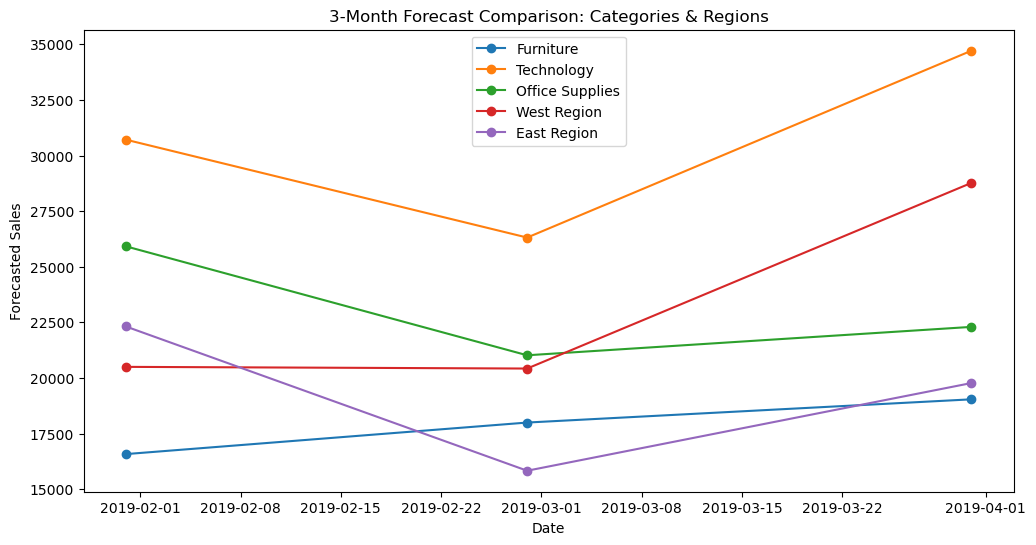

In [250]:
# Plotting all the forecasts together in one
plt.figure(figsize=(12,6))

plt.plot(forecast_furniture.index, forecast_furniture, label='Furniture', marker='o')
plt.plot(forecast_technology.index, forecast_technology, label='Technology', marker='o')
plt.plot(forecast_office.index, forecast_office, label='Office Supplies', marker='o')
plt.plot(forecast_west.index, forecast_west, label='West Region', marker='o')
plt.plot(forecast_east.index, forecast_east, label='East Region', marker='o')

plt.title('3-Month Forecast Comparison: Categories & Regions')
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.legend()
plt.savefig('allforecasts.png', dpi=300, bbox_inches='tight')

plt.show()

### Based on my model, the West region shows the strongest upcoming growth — its forecasted sales rise from about 20,500 to nearly 28,800 over the 3 months, roughly a 40% increase, the sharpest climb among all 5 segments. 

## ***Task 5 — Anomaly Detection in Sales Data***

In [187]:
# Using weekly sales data for anomaly detection
df_anomaly = df_weekly.copy()
df_anomaly

,Sales
Order Date,
2015-01-04,304.5080
2015-01-11,4619.1080
2015-01-18,4130.5330
2015-01-25,3092.5440
2015-02-01,2527.9140
...,...
2018-12-02,35998.9000
2018-12-09,21537.2410
2018-12-16,11542.8340


In [188]:
# Isolation Forest model
iso = IsolationForest(contamination=0.05, random_state=42)
df_anomaly['iso_anomaly'] = iso.fit_predict(df_anomaly[['Sales']])

# Conversion to labels
df_anomaly['iso_anomaly'] = df_anomaly['iso_anomaly'].map({1: 'Normal', -1: 'Anomaly'})

df_anomaly['iso_anomaly'].value_counts()

iso_anomaly
Normal     198
Anomaly     11
Name: count, dtype: int64

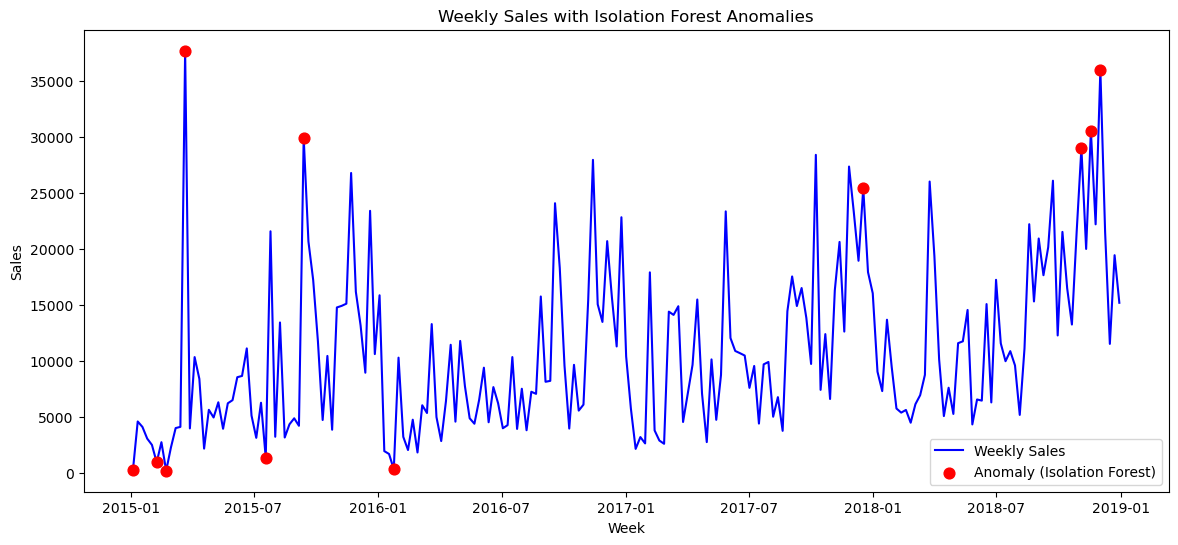

In [251]:
# PLotting the time series plot 
plt.figure(figsize=(14,6))
plt.plot(df_anomaly.index, df_anomaly['Sales'], label='Weekly Sales', color='blue')

anomalies_iso = df_anomaly[df_anomaly['iso_anomaly'] == 'Anomaly']
plt.scatter(anomalies_iso.index, anomalies_iso['Sales'], color='red', label='Anomaly (Isolation Forest)', s=60, zorder=5)

plt.title('Weekly Sales with Isolation Forest Anomalies')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.legend()
plt.savefig('isolation.png', dpi=300, bbox_inches='tight')

plt.show()

In [191]:
# Anamolies
anomalies_iso[['Sales']]

,Sales
Order Date,
2015-01-04,304.508
2015-02-08,968.534
2015-02-22,224.912
2015-03-22,37703.665
2015-07-19,1387.686
2015-09-13,29959.137
2016-01-24,358.522
2017-12-17,25449.800
2018-11-04,29017.467


## Real World Explanations
1) 2015-01-04 (304.5, low) — First week of January, post-holiday slowdown right after New Year.
2) 2015-02-08 (968.5, low) — Regular slow winter week, no major sale event.
3) 2015-02-22 (224.9, low) — Lowest point of the year, likely a lull before spring buying picks up.
4) 2015-03-22 (37703.7, high) — Sharp spike, possibly a large bulk/corporate order or end-of-quarter business purchasing.
5) 2015-07-19 (1387.7, low) — Mid-summer slowdown, typical seasonal dip before back-to-school demand.
6) 2015-09-13 (29959.1, high) — Back-to-school season driving higher purchases.
7) 2016-01-24 (358.5, low) — Post-holiday low, same pattern as other January dips.
8) 2017-12-17 (25449.8, high) — Pre-Christmas shopping rush.
9) 2018-11-04 (29017.5, high) — Early holiday season sales, possibly Black Friday lead-up.
10) 2018-11-18 (30572.4, high) — Black Friday/Thanksgiving week shopping surge.
11) 2018-12-02 (35998.9, high) — Cyber Monday and early December holiday shopping peak.

In [194]:
# Rolling mean and std (4-week rolling window, excluding current week)
df_anomaly['rolling_mean'] = df_anomaly['Sales'].shift(1).rolling(window=4).mean()
df_anomaly['rolling_std'] = df_anomaly['Sales'].shift(1).rolling(window=4).std()

# Z-score
df_anomaly['z_score'] = (df_anomaly['Sales'] - df_anomaly['rolling_mean']) / df_anomaly['rolling_std']

# Flag anomaly if |z_score| > 2
df_anomaly['zscore_anomaly'] = df_anomaly['z_score'].abs() > 2
df_anomaly['zscore_anomaly'] = df_anomaly['zscore_anomaly'].map({True: 'Anomaly', False: 'Normal'})

df_anomaly['zscore_anomaly'].value_counts()

zscore_anomaly
Normal     169
Anomaly     40
Name: count, dtype: int64

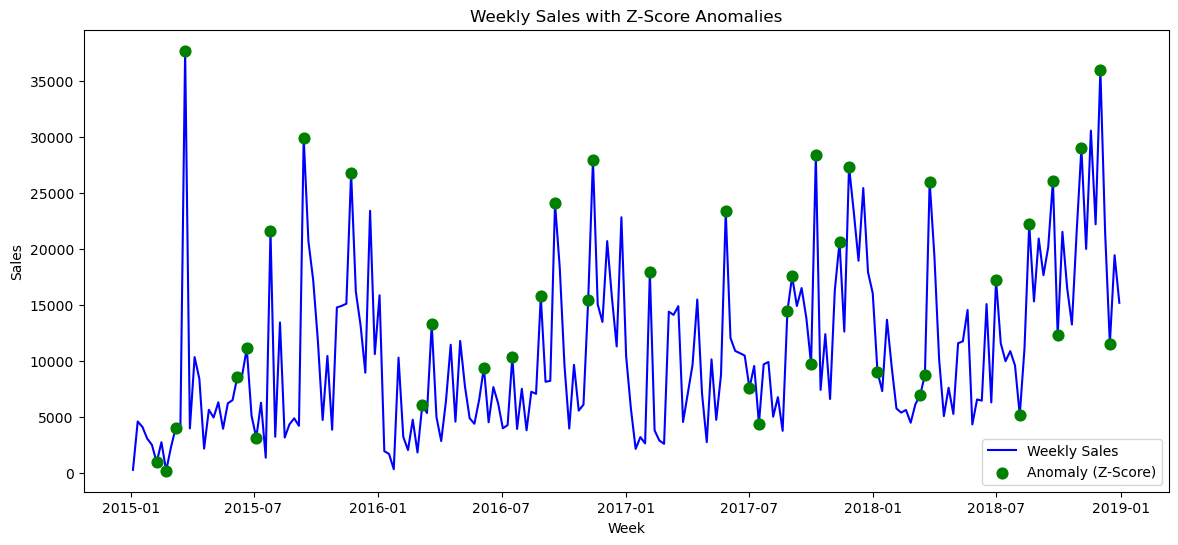

In [252]:
# Plotting the time series plot with Z-score anomalies
plt.figure(figsize=(14,6))
plt.plot(df_anomaly.index, df_anomaly['Sales'], label='Weekly Sales', color='blue')

anomalies_z = df_anomaly[df_anomaly['zscore_anomaly'] == 'Anomaly']
plt.scatter(anomalies_z.index, anomalies_z['Sales'], color='green', label='Anomaly (Z-Score)', s=60, zorder=5)

plt.title('Weekly Sales with Z-Score Anomalies')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.legend()
plt.savefig('z_score.png', dpi=300, bbox_inches='tight')

plt.show()

In [196]:
# Comparing Isolation Forest vs Z-score anomalies
common = anomalies_iso.index.intersection(anomalies_z.index)
only_iso = anomalies_iso.index.difference(anomalies_z.index)
only_z = anomalies_z.index.difference(anomalies_iso.index)

print("Flagged by both methods:", len(common))
print("Flagged only by Isolation Forest:", len(only_iso))
print("Flagged only by Z-score:", len(only_z))

Flagged by both methods: 6
Flagged only by Isolation Forest: 5
Flagged only by Z-score: 34


## Comparison of Anomaly Detection Methods
### Both methods agree on the biggest spikes (e.g. March 2015, Dec 2018), since these are extreme by any measure. Z-score flagged far more anomalies (40) than Isolation Forest, because it only looks at the last 4 weeks (local context), while Isolation Forest looks at the whole dataset (global context). So Z-score catches sudden local changes, Isolation Forest catches only the most extreme values overall.

## **Supplementary Dataset Anomaly Detection**

In [204]:
# Loading the supplementary dataset
df_games = pd.read_csv('vgsales.csv')
print(df_games)
# checking the data types
df_games.info()


        Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_Sales  \
0      2006.0        Sport

In [207]:
# checking null values
df_games.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [208]:
# Dropping rows with missing Year 
df_games = df_games.dropna(subset=['Year'])

# Year was stored as float (e.g. 2006.0), converting to int 
df_games['Year'] = df_games['Year'].astype(int)

# Aggregating total global sales by year

df_games_yearly = df_games.groupby('Year')['Global_Sales'].sum().reset_index()
df_games_yearly

,Year,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36
5,1985,53.94
6,1986,37.07
7,1987,21.74
8,1988,47.22
9,1989,73.45


In [209]:
# Running Isolation Forest on Supplementary Dataset
iso_games = IsolationForest(contamination=0.1, random_state=42)
df_games_yearly['iso_anomaly'] = iso_games.fit_predict(df_games_yearly[['Global_Sales']])
df_games_yearly['iso_anomaly'] = df_games_yearly['iso_anomaly'].map({1: 'Normal', -1: 'Anomaly'})

df_games_yearly['iso_anomaly'].value_counts()

iso_anomaly
Normal     35
Anomaly     4
Name: count, dtype: int64

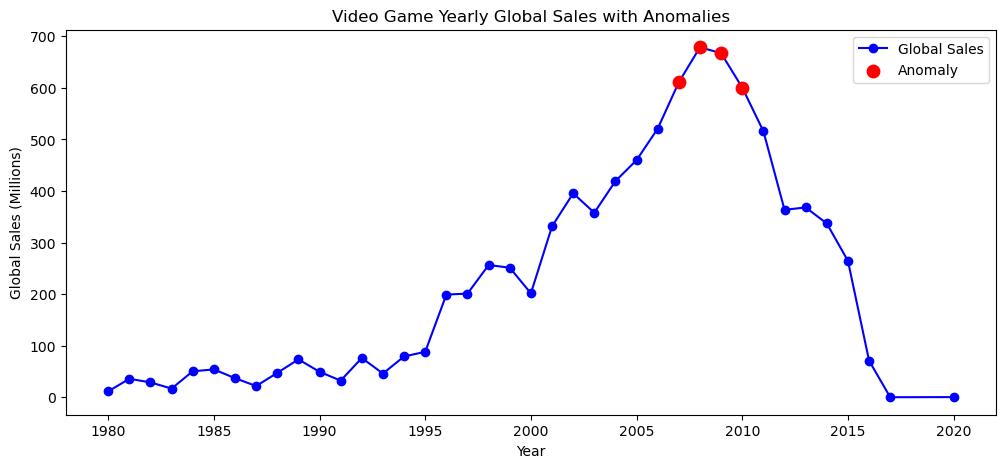

In [253]:
# Plotting the supplementary dataset 
plt.figure(figsize=(12,5))
plt.plot(df_games_yearly['Year'], df_games_yearly['Global_Sales'], label='Global Sales', color='blue', marker='o')

anomalies_games = df_games_yearly[df_games_yearly['iso_anomaly'] == 'Anomaly']
plt.scatter(anomalies_games['Year'], anomalies_games['Global_Sales'], color='red', label='Anomaly', s=80, zorder=5)

plt.title('Video Game Yearly Global Sales with Anomalies')
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')
plt.legend()
plt.savefig('videogame.png', dpi=300, bbox_inches='tight')

plt.show()

## Supplementary Dataset — Video Game Sales
### As a secondary dataset, I ran the same anomaly detection approach on video game yearly global sales. This confirms the method generalizes beyond the Superstore data — years with unusually high or low total sales (likely tied to major console launches or market shifts) get flagged the same way seasonal spikes were in the retail data.

## ***Task 6 — Product Demand Segmentation using Clustering***

In [211]:
# Aggregating data at Sub-Category level
seg = df_store.groupby('Sub-Category').agg(
    total_sales=('Sales', 'sum'),
    avg_order_value=('Sales', 'mean')
).reset_index()

seg

,Sub-Category,total_sales,avg_order_value
0,Accessories,164186.7000,217.178175
1,Appliances,104618.4030,227.926804
2,Art,26705.4100,34.019631
3,Binders,200028.7850,134.067550
4,Bookcases,113813.1987,503.598224
5,Chairs,322822.7310,531.833165
6,Copiers,146248.0940,2215.880212
7,Envelopes,16128.0460,65.032444
8,Fasteners,3001.9600,14.027850
9,Furnishings,89212.0180,95.823865


In [212]:
# Yearly sales per sub-category
yearly_sub = df_store.groupby(['Sub-Category', 'Year'])['Sales'].sum().reset_index()

# Growth rate = (last year sales - first year sales) / first year sales
def growth_rate(group):
    group = group.sort_values('Year')
    first = group['Sales'].iloc[0]
    last = group['Sales'].iloc[-1]
    return (last - first) / first

growth = yearly_sub.groupby('Sub-Category').apply(growth_rate).reset_index()
growth.columns = ['Sub-Category', 'growth_rate']

seg = seg.merge(growth, on='Sub-Category')
seg

C:\Users\singh\AppData\Local\Temp\ipykernel_2640\954504081.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth = yearly_sub.groupby('Sub-Category').apply(growth_rate).reset_index()


,Sub-Category,total_sales,avg_order_value,growth_rate
0,Accessories,164186.7000,217.178175,1.450560
1,Appliances,104618.4030,227.926804,1.652429
2,Art,26705.4100,34.019631,0.496495
3,Binders,200028.7850,134.067550,0.657786
4,Bookcases,113813.1987,503.598224,0.498466
5,Chairs,322822.7310,531.833165,0.209547
6,Copiers,146248.0940,2215.880212,4.797295
7,Envelopes,16128.0460,65.032444,-0.121213
8,Fasteners,3001.9600,14.027850,0.304684
9,Furnishings,89212.0180,95.823865,1.068250


In [213]:
# Monthly sales per sub-category
monthly_sub = df_store.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().reset_index()

# Volatility = how much monthly sales fluctuate — high std means unpredictable demand
volatility = monthly_sub.groupby('Sub-Category')['Sales'].std().reset_index()
volatility.columns = ['Sub-Category', 'volatility']

seg = seg.merge(volatility, on='Sub-Category')
seg

,Sub-Category,total_sales,avg_order_value,growth_rate,volatility
0,Accessories,164186.7000,217.178175,1.450560,2579.994809
1,Appliances,104618.4030,227.926804,1.652429,1821.621539
2,Art,26705.4100,34.019631,0.496495,330.488343
3,Binders,200028.7850,134.067550,0.657786,3848.223648
4,Bookcases,113813.1987,503.598224,0.498466,2220.405080
5,Chairs,322822.7310,531.833165,0.209547,4407.232960
6,Copiers,146248.0940,2215.880212,4.797295,5500.774391
7,Envelopes,16128.0460,65.032444,-0.121213,228.218688
8,Fasteners,3001.9600,14.027850,0.304684,48.742229
9,Furnishings,89212.0180,95.823865,1.068250,1360.017867


C:\Users\singh\NewAnaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\singh\NewAnaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\singh\NewAnaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\singh\NewAnaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak o

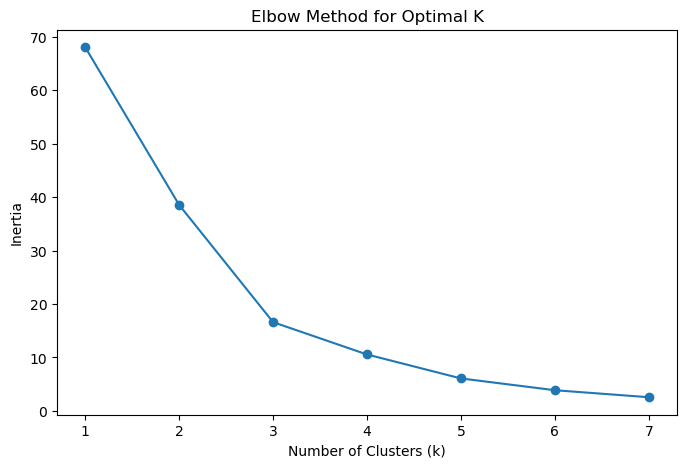

In [254]:
# Scaling features 
features = ['total_sales', 'avg_order_value', 'growth_rate', 'volatility']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(seg[features])

# Elbow Method - trying different cluster counts to find the optimal number
inertia = []
k_range = range(1, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.savefig('elbow.png', dpi=300, bbox_inches='tight')

plt.show()

In [219]:
# FInal Kmeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
seg['cluster'] = kmeans.fit_predict(X_scaled)

seg

C:\Users\singh\NewAnaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Sub-Category,total_sales,avg_order_value,growth_rate,volatility,cluster
0,Accessories,164186.7000,217.178175,1.450560,2579.994809,1
1,Appliances,104618.4030,227.926804,1.652429,1821.621539,1
2,Art,26705.4100,34.019631,0.496495,330.488343,1
3,Binders,200028.7850,134.067550,0.657786,3848.223648,2
4,Bookcases,113813.1987,503.598224,0.498466,2220.405080,1
5,Chairs,322822.7310,531.833165,0.209547,4407.232960,2
6,Copiers,146248.0940,2215.880212,4.797295,5500.774391,0
7,Envelopes,16128.0460,65.032444,-0.121213,228.218688,1
8,Fasteners,3001.9600,14.027850,0.304684,48.742229,1
9,Furnishings,89212.0180,95.823865,1.068250,1360.017867,1


In [221]:
# Labeling CLusters
cluster_labels = {
    0: 'High Growth, Premium Niche',
    1: 'Low Volume, Stable Demand',
    2: 'High Volume, Volatile Demand'
}

seg['cluster_label'] = seg['cluster'].map(cluster_labels)
seg

,Sub-Category,total_sales,avg_order_value,growth_rate,volatility,cluster,cluster_label
0,Accessories,164186.7000,217.178175,1.450560,2579.994809,1,"Low Volume, Stable Demand"
1,Appliances,104618.4030,227.926804,1.652429,1821.621539,1,"Low Volume, Stable Demand"
2,Art,26705.4100,34.019631,0.496495,330.488343,1,"Low Volume, Stable Demand"
3,Binders,200028.7850,134.067550,0.657786,3848.223648,2,"High Volume, Volatile Demand"
4,Bookcases,113813.1987,503.598224,0.498466,2220.405080,1,"Low Volume, Stable Demand"
5,Chairs,322822.7310,531.833165,0.209547,4407.232960,2,"High Volume, Volatile Demand"
6,Copiers,146248.0940,2215.880212,4.797295,5500.774391,0,"High Growth, Premium Niche"
7,Envelopes,16128.0460,65.032444,-0.121213,228.218688,1,"Low Volume, Stable Demand"
8,Fasteners,3001.9600,14.027850,0.304684,48.742229,1,"Low Volume, Stable Demand"
9,Furnishings,89212.0180,95.823865,1.068250,1360.017867,1,"Low Volume, Stable Demand"


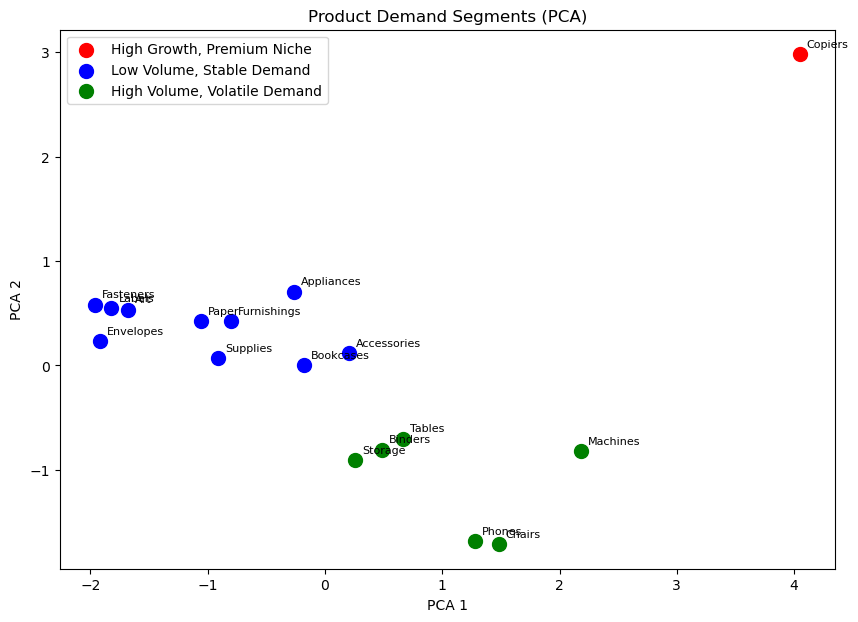

In [255]:
# Reducing our 4 features down to 2 dimensions just for visualization purposes
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

seg['pca1'] = pca_result[:, 0]
seg['pca2'] = pca_result[:, 1]

plt.figure(figsize=(10,7))
colors = {0: 'red', 1: 'blue', 2: 'green'}

for cluster_num, color in colors.items():
    cluster_data = seg[seg['cluster'] == cluster_num]
    plt.scatter(cluster_data['pca1'], cluster_data['pca2'], 
                label=cluster_labels[cluster_num], color=color, s=100)

# Adding sub-category names as labels on each point
for i, row in seg.iterrows():
    plt.annotate(row['Sub-Category'], (row['pca1'], row['pca2']), fontsize=8, xytext=(5,5), textcoords='offset points')

plt.title('Product Demand Segments (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.savefig('scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Recommended Stocking Strategy per Cluster

**Cluster 0 — High Growth, Premium Niche (Copiers):**
Low volume but high value and fast-growing. Keep smaller stock levels but reorder frequently
to avoid stockouts, since each unit sold has high impact on revenue.

**Cluster 1 — Low Volume, Stable Demand (Accessories, Appliances, Art, Bookcases,
Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies):**
Predictable, low-volatility demand. Can be stocked with standard reorder points and doesn't
need close monitoring — safe to hold moderate inventory levels.

**Cluster 2 — High Volume, Volatile Demand (Binders, Chairs, Machines, Phones, Storage,
Tables):**
High sales but unpredictable swings, and growth is flat or declining. Needs closer inventory
monitoring and safety stock buffers to handle demand spikes, but avoid overstocking since
long-term growth isn't guaranteed.

### ***Note: Tasks 7 and 8 are done separately***